# **Project Name**    - Strava Fitness



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

This project analyzes Strava user activity data to study daily movement, calorie burn, sleep records, and body indicators. The dataset includes variables such as total steps, total distance, tracker distance, active minutes, calories, sleep duration, weight, BMI, and fat percentage. Visualizations were used to understand the distribution of important features and the relationship between them.

Overall, the project provides insights into user fitness behavior, movement consistency, calorie patterns, and activity tracking, which can help businesses design better health-monitoring and user-engagement features.

# **GitHub Link -**

https://github.com/Shreya2700/Strava-Fitness/

# **Problem Statement**


Fitness applications like Strava, a large amount of user activity data is generated through walking, running, cycling, and workout tracking. However, users and fitness platforms may not fully utilize this data to understand activity patterns, calories burnt, workout consistency, and overall fitness behavior. This project aims to identify fitness trends and generate insights that can help improve user engagement, personalized recommendations, and fitness tracking performance.

### Import Libraries

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset

DS1 = pd.read_csv("dailyActivity_merged.csv")
DS2 = pd.read_csv("dailyCalories_merged.csv")
DS3 = pd.read_csv("dailyIntensities_merged.csv")
DS4 = pd.read_csv("dailySteps_merged.csv")
DS5 = pd.read_csv("sleepDay_merged.csv")
DS6 = pd.read_csv("weightLogInfo_merged.csv")

### Datasets Merged

In [3]:
from functools import reduce

# Dataset list
Datasets = [DS1, DS2, DS3, DS4, DS5, DS6]

# Possible date columns to check in each dataset
date_cols_DS = ['ActivityDate', 'ActivityDay', 'SleepDay', 'Date']

# Find date column in each dataset
def find_date_col(df):
    for col in date_cols_DS:
        if col in df.columns:
            return col
    return None

# List of (df, date_col) tuples
dfs_with_date_col = [(df, find_date_col(df)) for df in Datasets]

# Start merging
md = dfs_with_date_col[0][0]  # first dataframe

for df, date_col in dfs_with_date_col[1:]:
    if date_col is None:
        # No date column found, merge only on 'Id'
        md = pd.merge(md, df, on='Id', how='outer')
    else:
        # Merge on 'Id' and the date column (date columns might have different names)
        md = pd.merge(md, df, left_on=['Id', 'ActivityDate'] if 'ActivityDate' in md.columns else ['Id'],
                      right_on=['Id', date_col] if date_col else ['Id'],
                      how='outer')

### Dataset First View

In [33]:
# Dataset First Look

md.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance_x,ModeratelyActiveDistance_x,LightActiveDistance_x,SedentaryActiveDistance_x,...,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,2016-04-12,13162.0,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
58,1624580081,2016-04-12,8163.0,5.31,5.31,0.0,0.00,0.00,5.31,0.0,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
89,1644430081,2016-04-12,10694.0,7.77,7.77,0.0,0.14,2.30,5.33,0.0,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
123,1844505072,2016-04-12,6697.0,4.43,4.43,0.0,0.00,0.00,4.43,0.0,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
157,1927972279,2016-04-12,678.0,0.47,0.47,0.0,0.00,0.00,0.47,0.0,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count

md.shape

(1420, 39)

### Dataset Information

In [6]:
# Dataset Info

md.info()

<class 'pandas.DataFrame'>
RangeIndex: 1420 entries, 0 to 1419
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          1420 non-null   int64  
 1   ActivityDate                940 non-null    str    
 2   TotalSteps                  940 non-null    float64
 3   TotalDistance               940 non-null    float64
 4   TrackerDistance             940 non-null    float64
 5   LoggedActivitiesDistance    940 non-null    float64
 6   VeryActiveDistance_x        940 non-null    float64
 7   ModeratelyActiveDistance_x  940 non-null    float64
 8   LightActiveDistance_x       940 non-null    float64
 9   SedentaryActiveDistance_x   940 non-null    float64
 10  VeryActiveMinutes_x         940 non-null    float64
 11  FairlyActiveMinutes_x       940 non-null    float64
 12  LightlyActiveMinutes_x      940 non-null    float64
 13  SedentaryMinutes_x          940 non-null    

#### Duplicate Values

In [7]:
duplicate_count = md.duplicated(keep=False).value_counts()

print(duplicate_count)

False    1414
True        6
Name: count, dtype: int64


### Removing Duplicates

In [8]:
md.drop_duplicates(["Id"],keep='first',inplace=True)

In [9]:
md.duplicated().sum()

np.int64(0)

In [10]:
date_cols = ["ActivityDate", "ActivityDay_x", "ActivityDay_y", "ActivityDay",
       "SleepDay", "Date"]

for col in date_cols:
    md[col] = pd.to_datetime(md[col], errors="coerce").dt.normalize()

In [11]:
md.info()

<class 'pandas.DataFrame'>
Index: 33 entries, 0 to 1365
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          33 non-null     int64         
 1   ActivityDate                33 non-null     datetime64[us]
 2   TotalSteps                  33 non-null     float64       
 3   TotalDistance               33 non-null     float64       
 4   TrackerDistance             33 non-null     float64       
 5   LoggedActivitiesDistance    33 non-null     float64       
 6   VeryActiveDistance_x        33 non-null     float64       
 7   ModeratelyActiveDistance_x  33 non-null     float64       
 8   LightActiveDistance_x       33 non-null     float64       
 9   SedentaryActiveDistance_x   33 non-null     float64       
 10  VeryActiveMinutes_x         33 non-null     float64       
 11  FairlyActiveMinutes_x       33 non-null     float64       
 12  LightlyAct

#### Missing Values/Null Values

In [12]:
# Missing Values Count

md.isnull().sum()

Id                             0
ActivityDate                   0
TotalSteps                     0
TotalDistance                  0
TrackerDistance                0
LoggedActivitiesDistance       0
VeryActiveDistance_x           0
ModeratelyActiveDistance_x     0
LightActiveDistance_x          0
SedentaryActiveDistance_x      0
VeryActiveMinutes_x            0
FairlyActiveMinutes_x          0
LightlyActiveMinutes_x         0
SedentaryMinutes_x             0
Calories_x                     0
ActivityDay_x                  0
Calories_y                     0
ActivityDay_y                  0
SedentaryMinutes_y             0
LightlyActiveMinutes_y         0
FairlyActiveMinutes_y          0
VeryActiveMinutes_y            0
SedentaryActiveDistance_y      0
LightActiveDistance_y          0
ModeratelyActiveDistance_y     0
VeryActiveDistance_y           0
ActivityDay                    0
StepTotal                      0
SleepDay                      33
TotalSleepRecords             33
TotalMinut

In [13]:
md.fillna({'SleepDay': 0, 'TotalSleepRecords': 0,
           'TotalMinutesAsleep': 0, 'TotalTimeInBed': 0,
           'WeightKg': 0, 'WeightPounds': 0, 'Fat': 0,
           'BMI': 0, 'LogId': 0,
           'Date': 'Missing','IsManualReport': 'Missing'}, inplace=True)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance_x,ModeratelyActiveDistance_x,LightActiveDistance_x,SedentaryActiveDistance_x,...,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,2016-04-12,13162.0,8.50,8.50,0.000000,1.88,0.55,6.06,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
58,1624580081,2016-04-12,8163.0,5.31,5.31,0.000000,0.00,0.00,5.31,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
89,1644430081,2016-04-12,10694.0,7.77,7.77,0.000000,0.14,2.30,5.33,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
123,1844505072,2016-04-12,6697.0,4.43,4.43,0.000000,0.00,0.00,4.43,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
157,1927972279,2016-04-12,678.0,0.47,0.47,0.000000,0.00,0.00,0.47,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
194,2022484408,2016-04-12,11875.0,8.34,8.34,0.000000,3.31,0.77,4.26,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
225,2026352035,2016-04-12,4414.0,2.74,2.74,0.000000,0.19,0.35,2.20,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
284,2320127002,2016-04-12,10725.0,7.49,7.49,0.000000,1.17,0.31,6.01,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
316,2347167796,2016-04-12,10113.0,6.83,6.83,0.000000,2.00,0.62,4.20,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0
349,2873212765,2016-04-12,8796.0,5.91,5.91,0.000000,0.11,0.93,4.88,0.00,...,0.0,0.0,0.0,Missing,0.0,0.0,0.0,0.0,Missing,0.0


In [14]:
md.isnull().sum()

Id                            0
ActivityDate                  0
TotalSteps                    0
TotalDistance                 0
TrackerDistance               0
LoggedActivitiesDistance      0
VeryActiveDistance_x          0
ModeratelyActiveDistance_x    0
LightActiveDistance_x         0
SedentaryActiveDistance_x     0
VeryActiveMinutes_x           0
FairlyActiveMinutes_x         0
LightlyActiveMinutes_x        0
SedentaryMinutes_x            0
Calories_x                    0
ActivityDay_x                 0
Calories_y                    0
ActivityDay_y                 0
SedentaryMinutes_y            0
LightlyActiveMinutes_y        0
FairlyActiveMinutes_y         0
VeryActiveMinutes_y           0
SedentaryActiveDistance_y     0
LightActiveDistance_y         0
ModeratelyActiveDistance_y    0
VeryActiveDistance_y          0
ActivityDay                   0
StepTotal                     0
SleepDay                      0
TotalSleepRecords             0
TotalMinutesAsleep            0
TotalTim

### What did you know about your dataset? And what all manipulations have you done and insights you found?

1. There are 1402 rows and 39 columns
2. There are few NULL values filled them with appropriate values.
3. Few date columns are in str format, so converted themto correct date format
4. There were 6 duplicate rows, cleared them

## ***2. Understanding Your Variables***

In [15]:
# Dataset Columns

md.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance_x',
       'ModeratelyActiveDistance_x', 'LightActiveDistance_x',
       'SedentaryActiveDistance_x', 'VeryActiveMinutes_x',
       'FairlyActiveMinutes_x', 'LightlyActiveMinutes_x', 'SedentaryMinutes_x',
       'Calories_x', 'ActivityDay_x', 'Calories_y', 'ActivityDay_y',
       'SedentaryMinutes_y', 'LightlyActiveMinutes_y', 'FairlyActiveMinutes_y',
       'VeryActiveMinutes_y', 'SedentaryActiveDistance_y',
       'LightActiveDistance_y', 'ModeratelyActiveDistance_y',
       'VeryActiveDistance_y', 'ActivityDay', 'StepTotal', 'SleepDay',
       'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed', 'Date',
       'WeightKg', 'WeightPounds', 'Fat', 'BMI', 'IsManualReport', 'LogId'],
      dtype='str')

In [16]:
# Dataset Describe

md.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance_x,ModeratelyActiveDistance_x,LightActiveDistance_x,SedentaryActiveDistance_x,...,ActivityDay,StepTotal,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,WeightKg,WeightPounds,Fat,BMI,LogId
count,3.300000e+01,33,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.00000,33.000000,...,33,33.000000,33.0,33.0,33.0,33.0,33.0,33.0,33.0,33.0
mean,4.857201e+09,2016-04-12 00:00:00,8236.848485,5.982727,5.958182,0.215844,1.826364,0.346061,3.41000,0.000303,...,2016-04-12 00:00:00,8236.848485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,2016-04-12 00:00:00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.347168e+09,2016-04-12 00:00:00,5014.000000,3.450000,3.450000,0.000000,0.000000,0.000000,2.10000,0.000000,...,2016-04-12 00:00:00,5014.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.445115e+09,2016-04-12 00:00:00,8163.000000,5.980000,5.980000,0.000000,0.140000,0.240000,3.45000,0.000000,...,2016-04-12 00:00:00,8163.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,6.962181e+09,2016-04-12 00:00:00,10694.000000,7.570000,7.570000,0.000000,3.060000,0.550000,5.31000,0.000000,...,2016-04-12 00:00:00,10694.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,8.877689e+09,2016-04-12 00:00:00,23186.000000,20.400000,20.400000,4.869783,12.220000,2.300000,7.82000,0.010000,...,2016-04-12 00:00:00,23186.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,2.433765e+09,NaN,4873.667582,3.961760,3.936669,0.922865,3.105690,0.471420,2.06639,0.001741,...,NaN,4873.667582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Variables Description


1. The dataset contains user activity, sleep, and weight tracking information collected for different users across multiple dates.
2. Features like TotalSteps, TotalDistance, TrackerDistance, and StepTotal track the user daily activity.
3. Sleep-related variables like SleepDay, TotalSleepRecordscapture the user sleeping patterns.
4. Health-related features such as Weight, Fat, and BMI tells about the user body measurement.

### Check Unique Values for each variable.

In [17]:
# Check Unique Values for each variable

for uq in md.columns:
    print(f"{uq} - {md[uq].nunique()}") 

Id - 33
ActivityDate - 1
TotalSteps - 32
TotalDistance - 32
TrackerDistance - 32
LoggedActivitiesDistance - 3
VeryActiveDistance_x - 19
ModeratelyActiveDistance_x - 19
LightActiveDistance_x - 27
SedentaryActiveDistance_x - 2
VeryActiveMinutes_x - 18
FairlyActiveMinutes_x - 13
LightlyActiveMinutes_x - 29
SedentaryMinutes_x - 29
Calories_x - 32
ActivityDay_x - 1
Calories_y - 32
ActivityDay_y - 1
SedentaryMinutes_y - 29
LightlyActiveMinutes_y - 29
FairlyActiveMinutes_y - 13
VeryActiveMinutes_y - 18
SedentaryActiveDistance_y - 2
LightActiveDistance_y - 27
ModeratelyActiveDistance_y - 19
VeryActiveDistance_y - 19
ActivityDay - 1
StepTotal - 32
SleepDay - 1
TotalSleepRecords - 1
TotalMinutesAsleep - 1
TotalTimeInBed - 1
Date - 1
WeightKg - 1
WeightPounds - 1
Fat - 1
BMI - 1
IsManualReport - 1
LogId - 1


## ***3. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

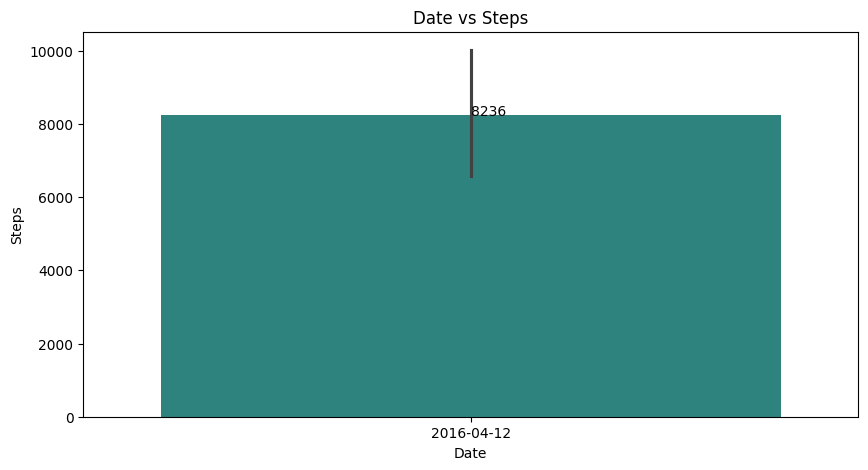

In [18]:
# Chart - 1 Date vs Steps

plt.figure(figsize=(10, 5)) 
ax = sns.barplot(data=md, x="ActivityDate", y="TotalSteps", hue="ActivityDate", palette="viridis", legend=False)

plt.xlabel("Date")
plt.ylabel("Steps")
plt.title("Date vs Steps")
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(str(count), (x, y))
plt.show()

##### 1. Why did you pick the specific chart?

The plot represents the step count taken at particular date

##### 2. What is/are the insight(s) found from the chart?

on 12-4-2016, the user has taken 8236 steps in total

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps to track user daily activity by showing the total number of steps taken in a day.

#### Chart - 2

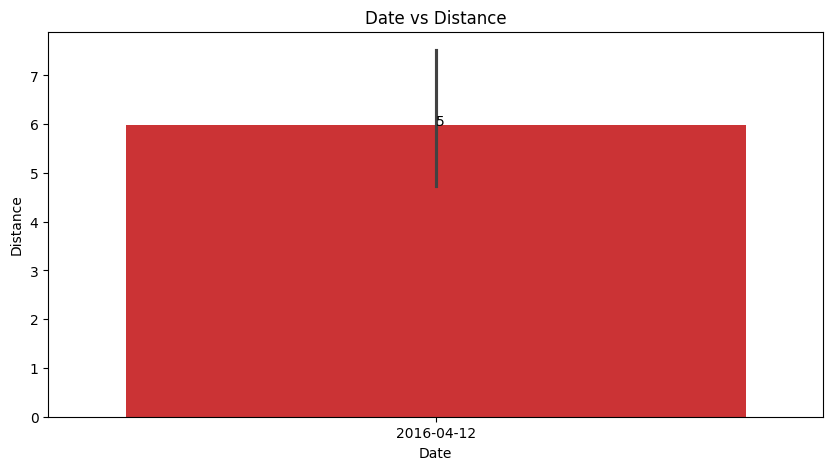

In [19]:
# Chart - 2 Date vs Distance

plt.figure(figsize=(10, 5)) 
ax = sns.barplot(data=md, x="ActivityDate", y="TotalDistance", hue="ActivityDate", palette="Set1", legend=False)
 
plt.xlabel("Date")
plt.ylabel("Distance")
plt.title("Date vs Distance")
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(str(count), (x, y))
plt.show()

##### 1. Why did you pick the specific chart?

The plot represents the total distance covered by the user on that day

##### 2. What is/are the insight(s) found from the chart?

on 12-4-2016, the user covered 5km distance

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps to track user daily activity by showing the total distance achieved.

#### Chart - 3

In [20]:
# Chart - 3 Total Steps Frequency

import plotly.express as px

# Occurrences of each start station
step_count = md["TotalSteps"].value_counts().reset_index()
step_count.columns = ["TotalSteps", "Count"]

fig = px.treemap(step_count, path=['TotalSteps'], values='Count', title="Frequency of Total Steps",color='Count', color_continuous_scale="Viridis")
fig.show()

##### 1. Why did you pick the specific chart?

The plot shows how many times each total step count was recorded.

##### 2. What is/are the insight(s) found from the chart?

1. Label id 0 has 2 count.
2. And the remaining ids having count as 1

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps to track the highest number of steps taken by the user and set daily step targets. Implementing reward-based features, where users earn reward points for achieving their target step count.

#### Chart - 4

In [21]:
# Chart - 4 Frequency of Distance Covered

# Occurrences of each start station
distance_count = md["TotalDistance"].value_counts().reset_index()
distance_count.columns = ["TotalDistance", "Count"]

fig = px.treemap(distance_count, path=['TotalDistance'], values='Count', title="Frequency of Total Distance Covered", color='Count', color_continuous_scale="Blues")
fig.show()

##### 1. Why did you pick the specific chart?

The plot shows how many times each distance was recorded.

##### 2. What is/are the insight(s) found from the chart?

All distance records have count 1, except label 0 with count 2

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The distance covered by users is varying daily, indicating that daily activity is not consistent. This variation may be due to differences in the number of steps taken, skipping the activity or changes in daily schedules.

#### Chart - 5

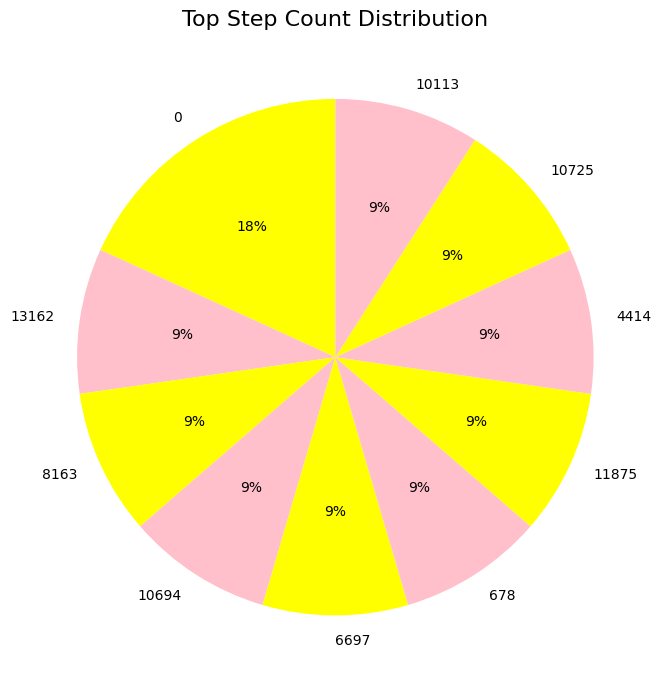

In [22]:
# Chart - 5 Step Count Distribution

co = md['StepTotal'].value_counts().head(10)
co.index = co.index.astype(int)

plt.figure(figsize=(15, 7))
co.plot(kind='pie', labels=[str(year) for year in co.index], autopct=lambda p:'{:.0f}%'.format(p), colors=['yellow', 'pink'],startangle=90)

plt.title('Top Step Count Distribution', fontsize=16)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The plot respresents distribution of total step counts

##### 2. What is/are the insight(s) found from the chart?

1. 0 has highest distribution with 18%
2. Followed by 10113, 10725 and other with 9%

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps to track the highest number of steps taken by the user and set daily step targets. Implementing reward-based features, where users earn reward points for achieving their target step count.

#### Chart - 6

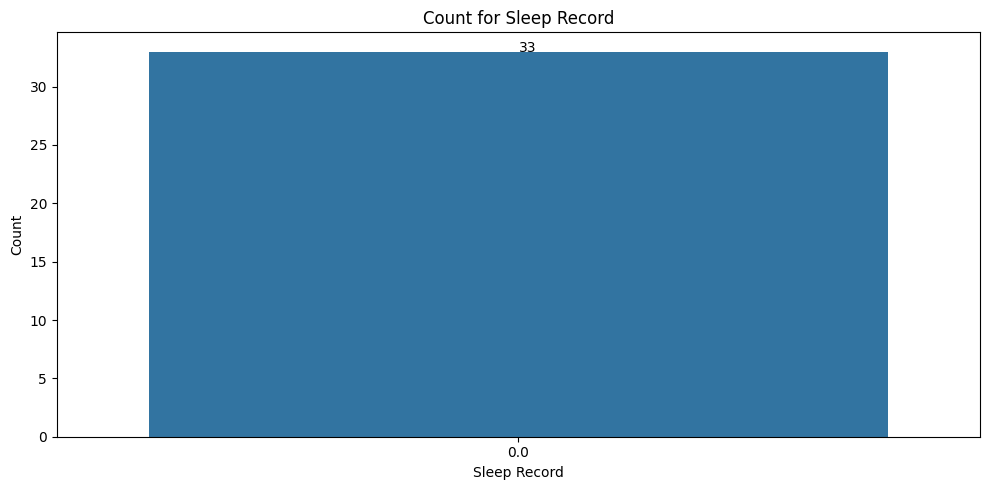

In [23]:
# Chart - 6 Sleep Record count

plt.figure(figsize=(10, 5))
ax = sns.countplot(x='TotalSleepRecords', data=md)

plt.title('Count for Sleep Record')
plt.xlabel('Sleep Record')
plt.ylabel('Count')
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(str(count), (x, y))
plt.grid(False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The plot represents the total sleep record covered by the user on that day

##### 2. What is/are the insight(s) found from the chart?

All the records having sleep record as 0.0

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The plot indicates that the sleep record value is 0.0, which says that users were not wearing the device during sleep hours. To improve sleep tracking and understand the patterns, users should be encouraged to wear the device during sleep.

#### Chart - 7

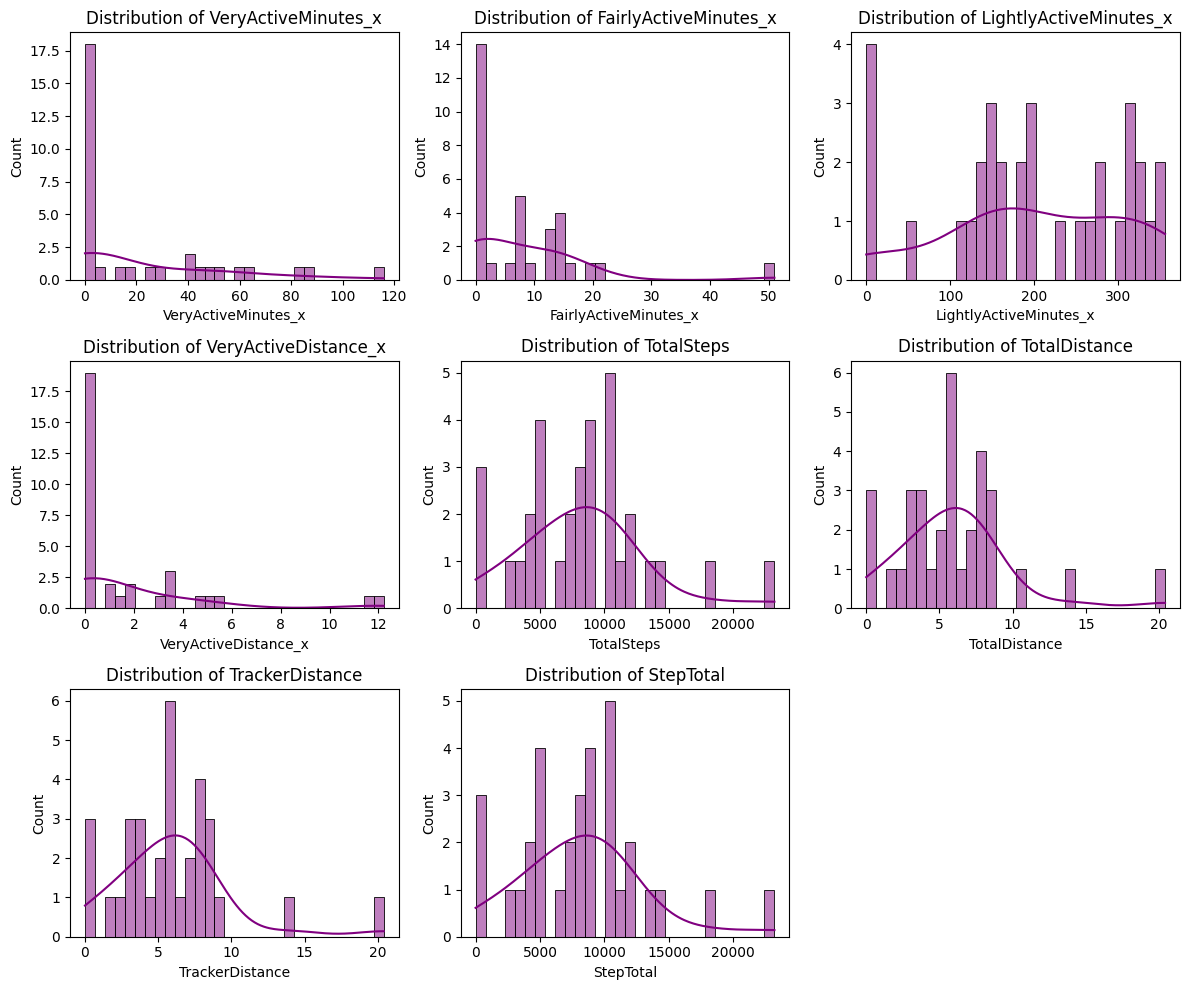

In [24]:
# Chart - 7 Distribution of tracking features

numeric = ['VeryActiveMinutes_x','FairlyActiveMinutes_x','LightlyActiveMinutes_x','VeryActiveDistance_x',
                     'TotalSteps','TotalDistance','TrackerDistance','StepTotal']

plt.figure(figsize=(12, 10))
for x, column in enumerate(numeric, 1):
    plt.subplot(3, 3, x)
    sns.histplot(md[column], kde=True, bins=30, color='purple')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.grid(False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The plot represents the distribution of the feature with itself, showing how the values of the variable are spread across the dataset.

##### 2. What is/are the insight(s) found from the chart?

Highest recorded values:
1. Active mins around 17.5
2. Fairly active: 14 mins'
3. Light active: 4 mins
4. Active distance: 18km
5. 10000 step count achived 5 times
6. Distance about 6km

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights would be helpful for user to track the activity details, and set a certain target to improve the overall performance, by setting up daily or weekly goals to be consistent.

#### Chart - 8

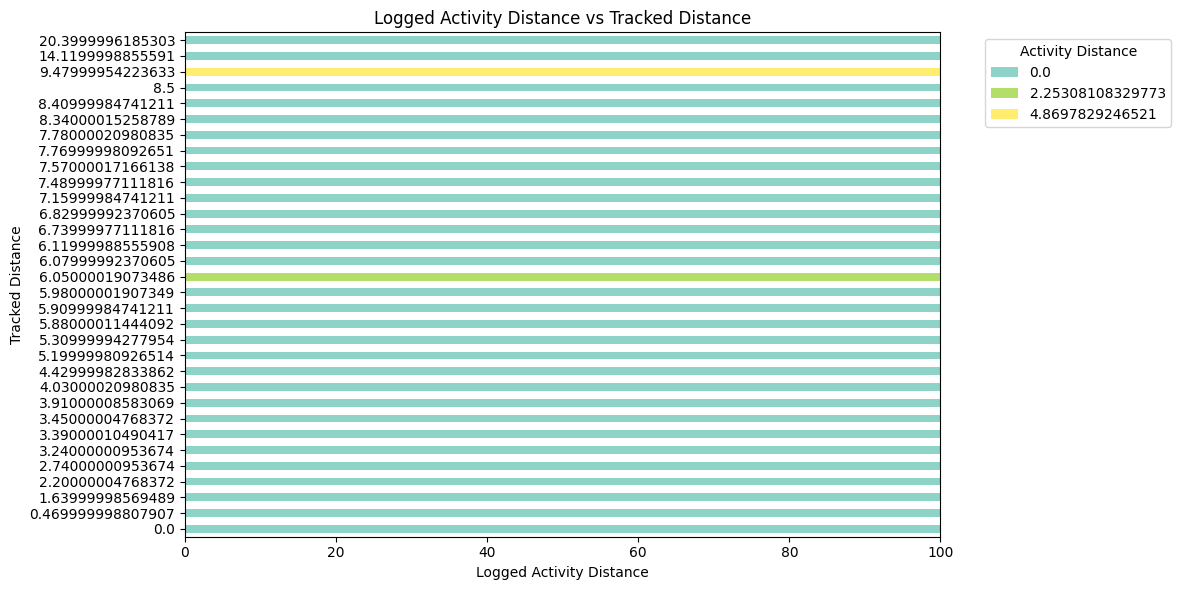

In [25]:
# Chart - 8 visualization code

data = md.groupby(["TrackerDistance", "LoggedActivitiesDistance"]).size().unstack(fill_value=0)

# Percentage distribution
data1 = data.div(data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6)) 
data1.plot(kind="barh", stacked=True, colormap="Set3", ax=ax)

# Labels and title
plt.xlabel("Logged Activity Distance")
plt.ylabel("Tracked Distance")
plt.title("Logged Activity Distance vs Tracked Distance")
plt.legend(title="Activity Distance", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This plot is useful for showing various entities distribution for single variable value.

##### 2. What is/are the insight(s) found from the chart?

1. Logged Activity Distance is 0 for most tracked-distance values
2. Few records have logged activity values such as 2.25 for tracked distance 6.05 and 4.86 for tracked distance 9.47

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

From the plot we can see that users more dependent on automatic tracking than manual logging, the tracker can focus on improving the accuracy, usability, and syncing of automatic activity tracking.

#### Chart - 9

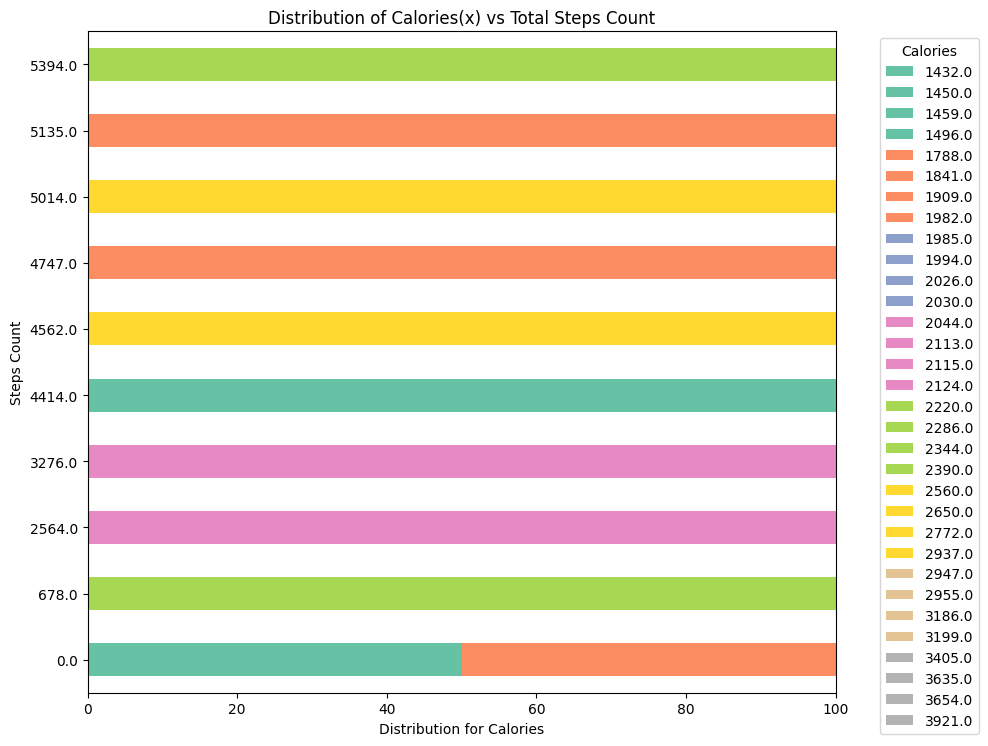

In [26]:
# Chart - 9 Calorie distribution(x)

dataC = md.groupby(["TotalSteps", "Calories_x"]).size().unstack(fill_value=0)

# Percentage distribution
dataC1 = dataC.div(dataC.sum(axis=1), axis=0) * 100

# Top stations by total trip count
TotalSteps = dataC.sum(axis=1).sort_values(ascending=False).head(10).index
TotalSteps1 = dataC1.loc[TotalSteps]

fig, ax = plt.subplots(figsize=(10, 8))
TotalSteps1.plot(kind="barh", stacked=True, colormap="Set2", ax=ax)

plt.xlabel("Distribution for Calories")
plt.ylabel("Steps Count")
plt.title("Distribution of Calories(x) vs Total Steps Count")
plt.legend(title="Calories", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This plot is useful for showing various entities distribution for single variable value.

##### 2. What is/are the insight(s) found from the chart?

1. For step count 0, the distribution is done 1432 calories and 1788 calories 
2. Followed by other steps count distributed among the calories

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This will help to create personalized activity goals, calorie targets, and rewards. Encouraging users to increase step counts can improve health.

#### Chart - 10

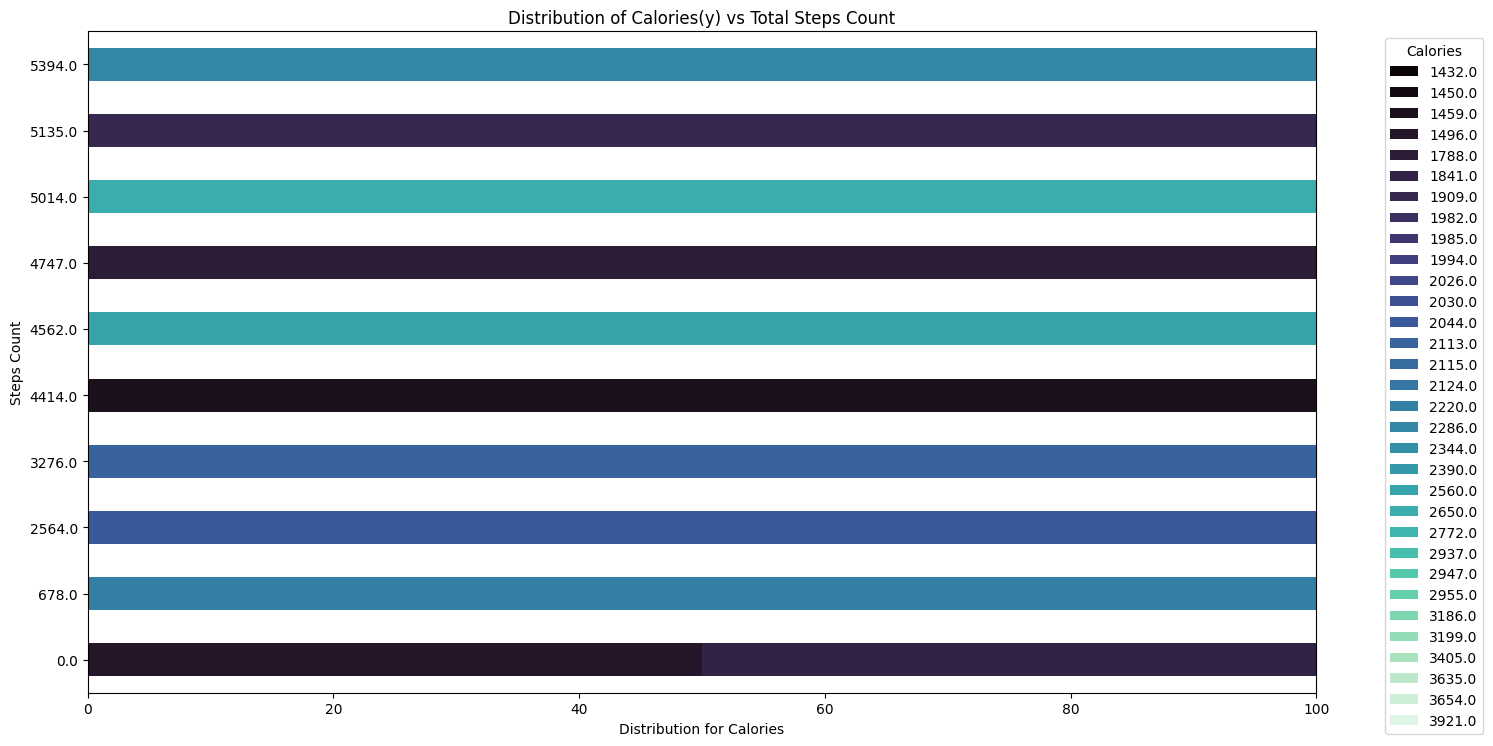

In [27]:
# Chart - 10 Calorie distribution(y)

dataY = md.groupby(["TotalSteps", "Calories_y"]).size().unstack(fill_value=0)

# Percentage distribution
dataY1 = dataY.div(dataY.sum(axis=1), axis=0) * 100

# Top stations by total trip count 
TotalSteps_ = dataY.sum(axis=1).sort_values(ascending=False).head(10).index
TotalSteps_1 = dataY1.loc[TotalSteps_]

fig, ax = plt.subplots(figsize=(15, 8))  
TotalSteps_1.plot(kind="barh", stacked=True, colormap="mako", ax=ax)

plt.xlabel("Distribution for Calories")
plt.ylabel("Steps Count")
plt.title("Distribution of Calories(y) vs Total Steps Count")
plt.legend(title="Calories", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This plot is useful for showing various entities distribution for single variable value.

##### 2. What is/are the insight(s) found from the chart?

1. For step count 0, the distribution is done 1459 calories and 1982 calories
2. Followed by other steps count distributed among the calories

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This will help to create personalized activity goals, calorie targets, and rewards. Encouraging users to increase step counts can improve health.

#### Chart - 11

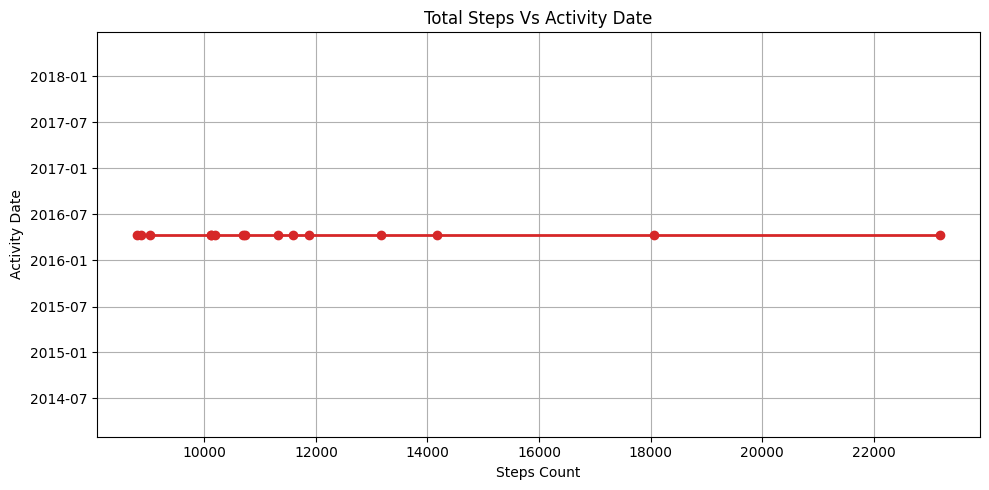

In [28]:
# Chart - 11 Total Steps Vs Activity Date

# Sort by date_added and release_year
top_dates = md[['TotalSteps', 'ActivityDate']].sort_values(by='TotalSteps', ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.plot(top_dates['TotalSteps'], top_dates['ActivityDate'], marker="o", color='tab:red', linestyle='-', linewidth=2)

plt.xlabel("Steps Count")
plt.ylabel("Activity Date")
plt.title("Total Steps Vs Activity Date")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This plot shows trend analysis of a variable over a specific period of time.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a stable trend in total steps across activity dates. Most of the step count are concentrated between 0 and 14000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The highest observations lies between 0 and 14000 steps which indicates that most users maintain their daily step count within this range. Through this we can create pop-ups to motivate the users to increase the daily to few more steps to complete certain levels in the app.

#### Chart - 12

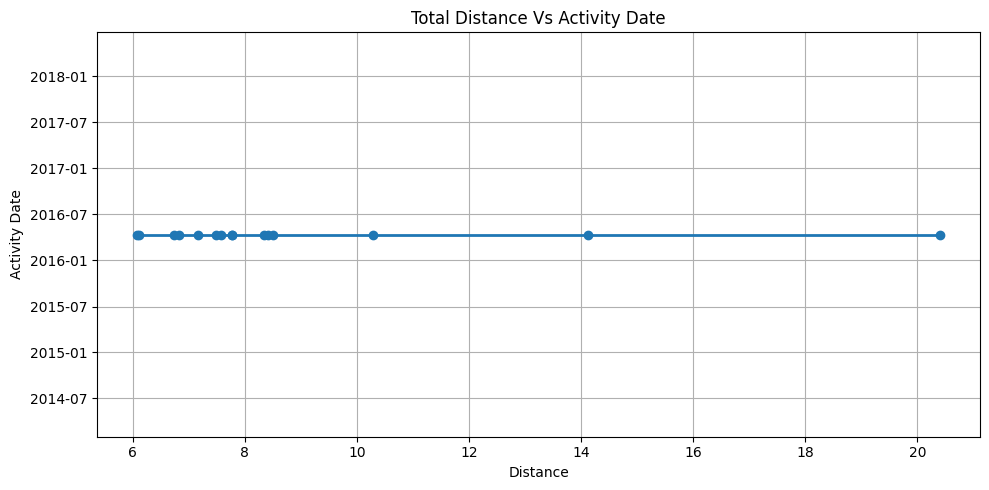

In [29]:
# Chart - 12 Total Distance Vs Activity Date

# Sort by distance and release_year
top_distance = md[['TotalDistance', 'ActivityDate']].sort_values(by='TotalDistance', ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.plot(top_distance['TotalDistance'], top_distance['ActivityDate'], marker="o", color='tab:blue', linestyle='-', linewidth=2)

plt.xlabel("Distance")
plt.ylabel("Activity Date")
plt.title("Total Distance Vs Activity Date")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This plot shows trend analysis of a variable over a specific period of time.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a stable trend in total distance covered. The common distance covered is between 6 to 9.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The common distance covered lies between 6-9 steps which indicates that most users maintain their daily distance within this range. Through this we can create pop-ups to motivate the users to increase the daily to some more distance to complete certain levels in the app.

#### Chart - 13

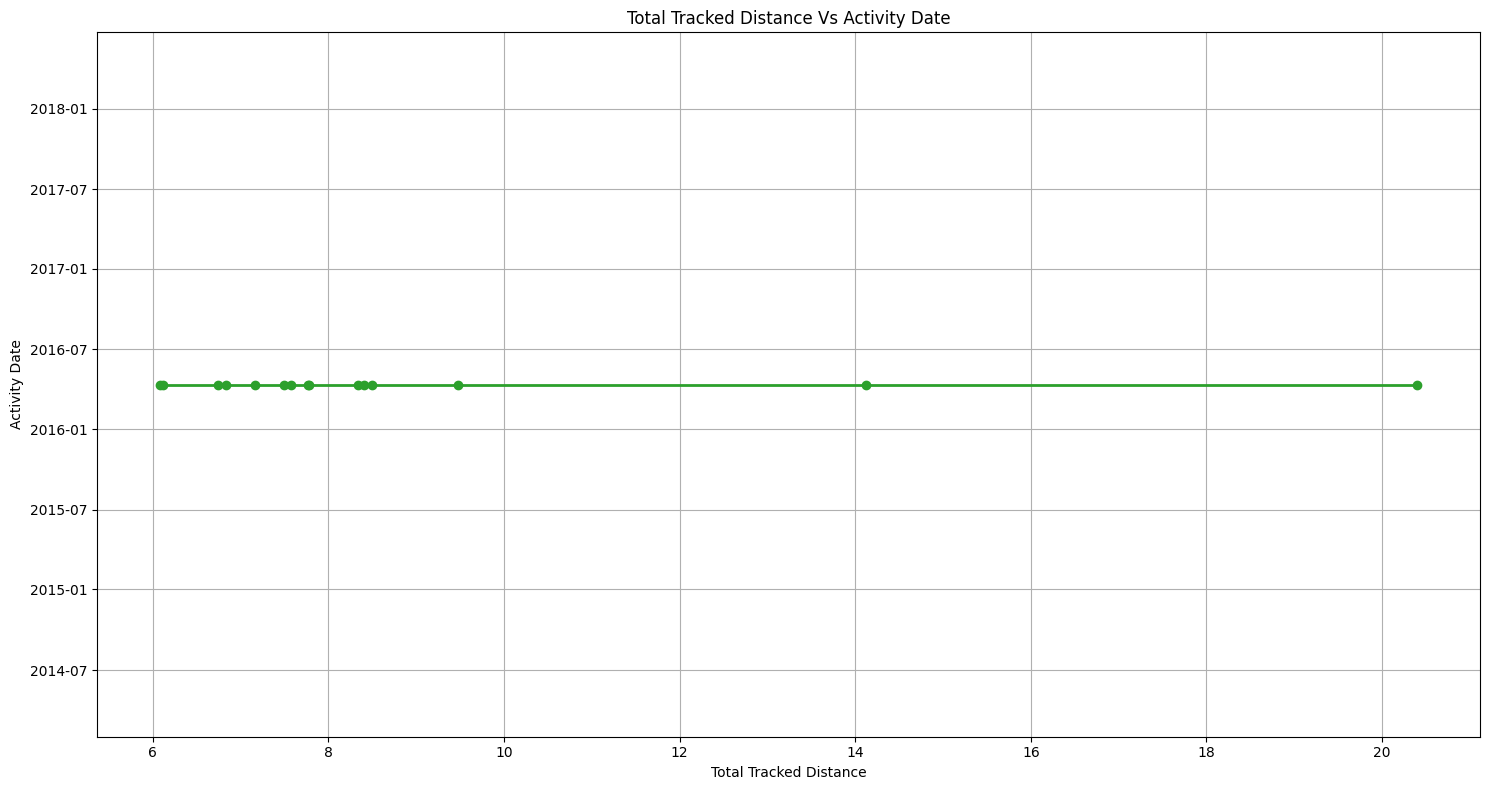

In [30]:
# Chart - 13 Tracked Distance Vs Activity Date

# Sort by Tracker distance and release_year
top_tracked = md[['TrackerDistance', 'ActivityDate']].sort_values(by='TrackerDistance', ascending=False).head(15)

# Plot the results
plt.figure(figsize=(15, 8))
plt.plot(top_tracked['TrackerDistance'], top_tracked['ActivityDate'], marker="o", color='tab:green', linestyle='-', linewidth=2)

plt.xlabel("Total Tracked Distance")
plt.ylabel("Activity Date")
plt.title("Total Tracked Distance Vs Activity Date")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This plot shows trend analysis of a variable over a specific period of time.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a stable trend in total tracked distance covered. The common distance covered is between 6 to 9.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The common distance covered lies between 6-9 steps which indicates that most users maintain their daily distance within this range. Through this we can create pop-ups to motivate the users to increase the daily to some more distance to complete certain levels in the app.

#### Chart - 14 - Correlation Heatmap

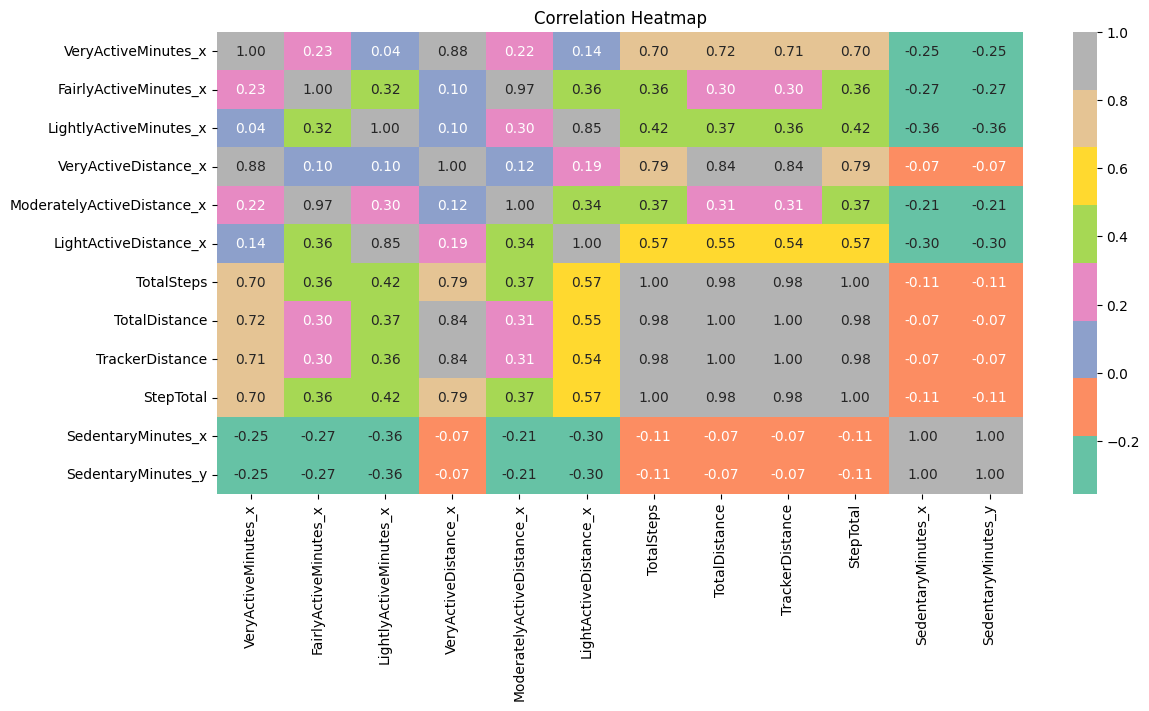

In [31]:
# Correlation Heatmap visualization code

corr_cols = ['VeryActiveMinutes_x','FairlyActiveMinutes_x','LightlyActiveMinutes_x','VeryActiveDistance_x',
             'ModeratelyActiveDistance_x','LightActiveDistance_x','TotalSteps','TotalDistance','TrackerDistance',
             'StepTotal','SedentaryMinutes_x','SedentaryMinutes_y']
md1 = md[corr_cols]

md2 = md1.corr()

plt.figure(figsize=(13, 6))
sns.heatmap(md2, annot=True, cmap="Set2", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

The matrix shows the correlation between various numerical variables.

##### 2. What is/are the insight(s) found from the chart?

1. The highest correlation is between Steps count and DIstance covered with 0.98.
2. Followed by moderately active distance and Fairly active minutes with 0.97.

#### Chart - 15 - Pair Plot

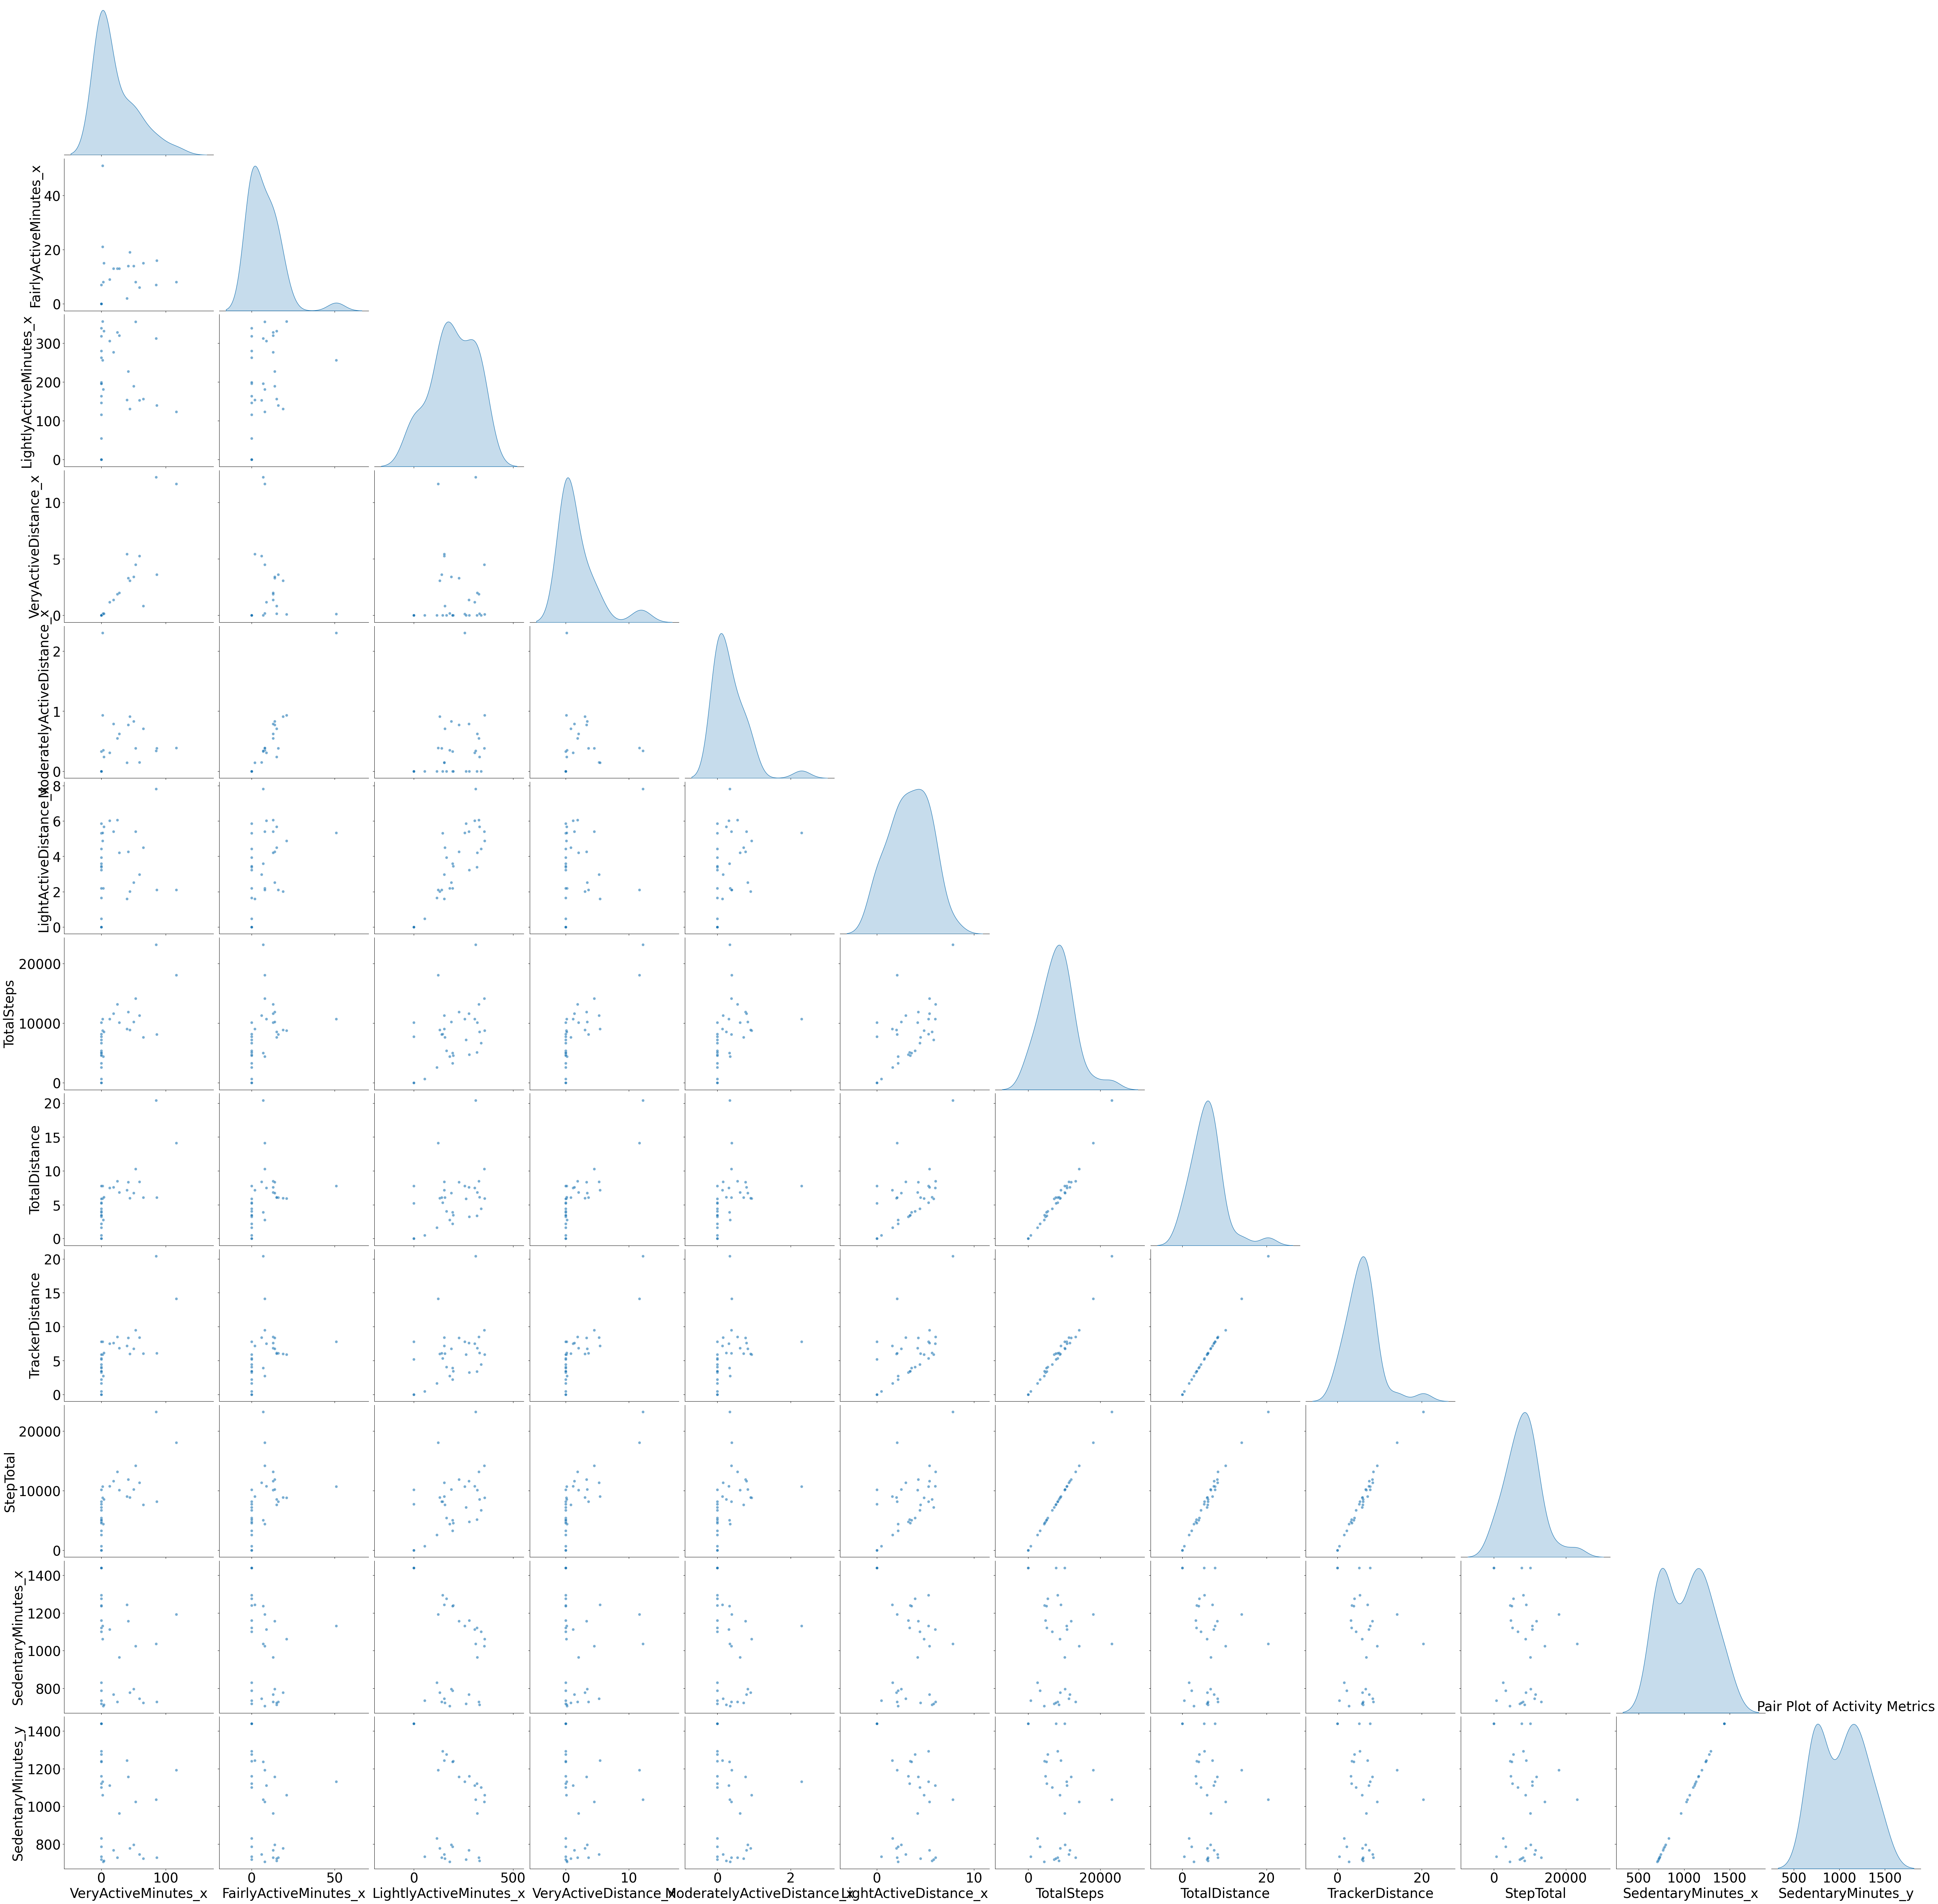

In [32]:
# Pair Plot 

Paircolumns = ['VeryActiveMinutes_x','FairlyActiveMinutes_x','LightlyActiveMinutes_x','VeryActiveDistance_x',
               'ModeratelyActiveDistance_x','LightActiveDistance_x','TotalSteps','TotalDistance','TrackerDistance',
               'StepTotal','SedentaryMinutes_x','SedentaryMinutes_y']
md2 = md[Paircolumns]

g = sns.pairplot(md2, corner=True, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40}, height=5, aspect=1)   
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(axis='both', labelsize=30)  
        ax.xaxis.label.set_size(30)                 
        ax.yaxis.label.set_size(30)                 
plt.title("Pair Plot of Activity Metrics", y=1.02, fontsize=30)
plt.show()

##### 1. Why did you pick the specific chart?

This plot represents comparision of various numerical variables in trend analysis style.

##### 2. What is/are the insight(s) found from the chart?

The features are not positively related, as there is no linearlity between them, indicating variations. So we cannot predict based upon single relation, various other features also needs to be considered.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. Personalized goals should be implemented since most users fall within a moderate range of daily steps and activity, the app can recommend personalized goals rather than one fixed target for all users.
2. The app can introduce challenges, streak rewards, and badges, to encourage users to increase activity levels.
3. To focus on tracker accuracy, sync reliability, and automatic activity detection since users are more dependent on automatic logging.
4. Using health features, suggesting personalized diet, and workouts.
5. Reminder/ Notifications to users to wear the trackers while sleeping

# **Conclusion**

From the analysis, it shows that users generally maintain moderate and routine-based physical activity, with daily step counts and distances concentrated in a common range. Most users are more involved in light to moderate activities, while high-intensity exercise is less frequent, as seen from the lower values of very active and fairly active minutes. At the same time, sleep records are mostly zero, which limits sleep analysis and suggests inconsistent tracker usage during sleep. The comparison charts also show that step count, distance, and calories are positively related, which means users who move more tend to cover more distance and burn more calories. Logged activity distance is almost always zero, indicating that users depend primarily on automatic tracker-based activity recording rather than manually logging their activities. 

By improving sleep tracking, personalized goal setting, and automatic activity detection, can help create a more effective and valuable fitness-tracking platform.